In [4]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
from cycler import cycler


In [5]:
default_cycler = cycler(color=['#000000', '#6a6a6a', '#bebebe', '#2a2eec'])
plt.rc('axes', prop_cycle=default_cycler)
plt.rc('figure', dpi=300, figsize=(12, 4))
np.random.seed(42)

In [7]:
cs_data = pd.read_csv('../code/data/chemical_shifts_theo_exp.csv')
cs_data.tail()

,ID,aa,theo,exp,cat
1771,1KS9,LYS,55.79,57.51,Charged
1772,1KS9,ARG,58.91,59.02,Charged
1773,1KS9,LYS,59.49,58.92,Charged
1774,1KS9,GLU,59.48,58.36,Charged
1775,1KS9,SER,58.07,60.55,Polar


In [8]:
diff = cs_data.theo - cs_data.exp
cat_encode = pd.Categorical(cs_data['aa'])
cat_encode

['ILE', 'TYR', 'SER', 'ALA', 'ARG', ..., 'LYS', 'ARG', 'LYS', 'GLU', 'SER']
Length: 1776
Categories (19, object): ['ALA', 'ARG', 'ASN', 'ASP', ..., 'THR', 'TRP', 'TYR', 'VAL']

In [9]:
idx = cat_encode.codes
idx

array([ 8, 17, 14, ..., 10,  5, 14], dtype=int8)

In [10]:
coords = {'aa': cat_encode.categories}
coords

{'aa': Index(['ALA', 'ARG', 'ASN', 'ASP', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU',
        'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL'],
       dtype='object')}

In [11]:
# Regular model
with pm.Model(coords=coords) as cs_nh:
    µ = pm.Normal('µ', mu=0, sigma=10, dims='aa')
    σ = pm.HalfNormal('σ', sigma=10, dims='aa')
    y = pm.Normal('y', mu=µ[idx], sigma=σ[idx], observed=diff)

    idata_cs_nh = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [µ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [13]:
# Hierarchical model
with pm.Model(coords=coords) as cs_h:
    # hyperpriors
    µ_mu = pm.Normal('µ_mu', mu=0, sigma=10)
    µ_sd = pm.HalfNormal('µ_sd', sigma=10)
    # priors
    µ = pm.Normal('µ', mu=µ_mu, sigma=µ_sd, dims='aa')
    σ = pm.HalfNormal('σ', sigma=10, dims='aa')
    # likelihood
    y = pm.Normal('y', mu=µ[idx], sigma=σ[idx], observed=diff)

    idata_cs_h = pm.sample(random_seed=4591)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [µ_mu, µ_sd, µ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


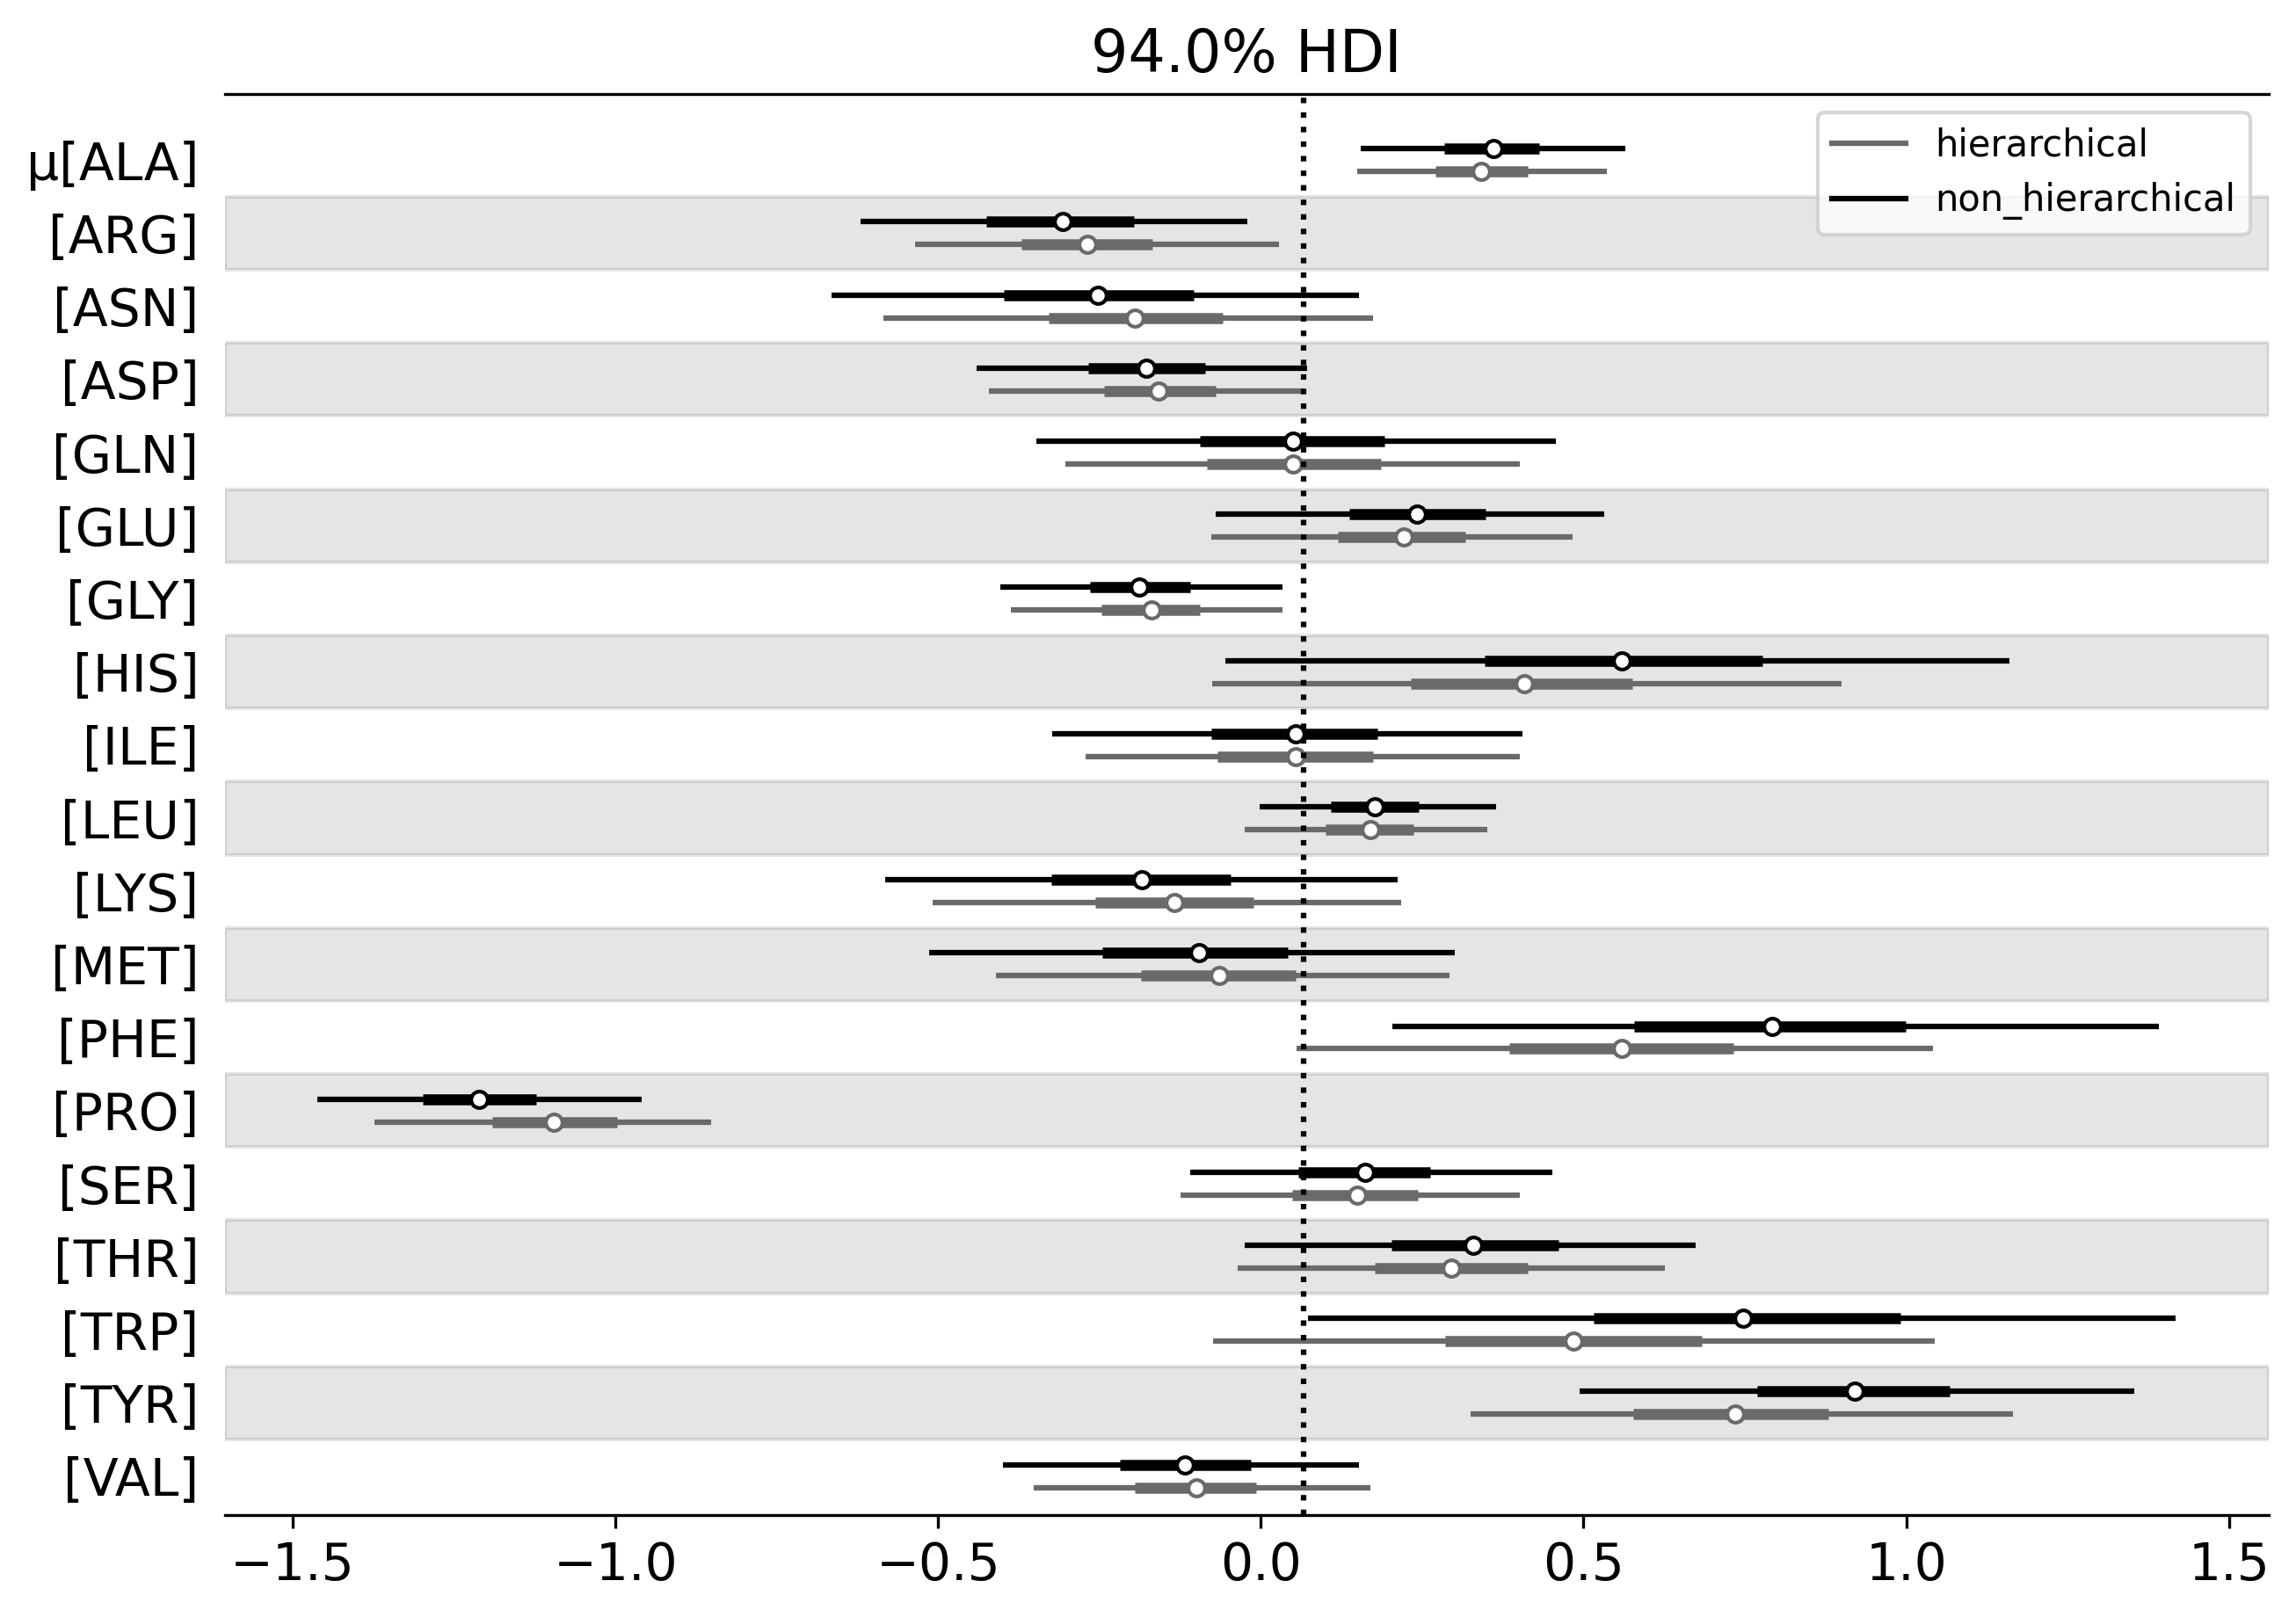

In [17]:
axes = az.plot_forest([idata_cs_nh, idata_cs_h], model_names=['non_hierarchical', 'hierarchical'],
                      var_names='µ', combined=True, r_hat=False, ess=False, figsize=(10, 7), colors='cycle')
y_lims = axes[0].get_ylim()
axes[0].vlines(idata_cs_h.posterior['µ_mu'].mean(), *y_lims, color='k', ls=':')
plt.savefig('fig/csh_csv_csnh.png')